# 04 - Official Denormalized Open-Loop Evaluation

K-step Euler ODE inference. MSE/MAE/RMSE are computed on **raw denormalized action space**.

This notebook evaluates the Notebook 03b pretrain and posttrain checkpoints on the full multi-batch H16 test split. It reads 4 prepared-data batch outputs, 4 frozen-VLM encoded-feature batch outputs, and the Notebook 03b DiT/action-head run output. NVIDIA GR00T zero-shot is optional-safe: if the model cannot be loaded offline or does not expose a compatible action API, the row is marked `skipped` instead of crashing the notebook.


In [1]:
# Kaggle images used for this project already include the required runtime packages.
# Keep this cell offline-safe: do not pip install, because RTX6000/Nemotron sessions may not allow internet.


In [2]:
from pathlib import Path
import json, math, time, random, os
import numpy as np, pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

try:
    from transformers import AutoModel, AutoProcessor
except Exception:
    AutoModel = None; AutoProcessor = None

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available(): print("gpu:", torch.cuda.get_device_name(0))

SMOKE_TEST = False
ACTION_HORIZON = 16
STATE_HORIZON = 1
K = int(os.getenv("EVAL_K", "4"))
MAX_EVAL_SAMPLES = 2048 if SMOKE_TEST else None
BATCH_SIZE = int(os.getenv("EVAL_BATCH_SIZE", "512"))
NUM_WORKERS = 2
USE_AMP = True
RUN_NVIDIA_ZEROSHOT = True
NVIDIA_MODEL_ID = "nvidia/GR00T-N1.6-3B"
EXPECTED_PREPARED_BATCHES = int(os.getenv("EXPECTED_PREPARED_BATCHES", "4"))
EXPECTED_ENCODED_BATCHES = int(os.getenv("EXPECTED_ENCODED_BATCHES", "4"))
OUTPUT_ROOT = Path("/kaggle/working/gr00t_official_eval")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


device: cuda
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
REQUIRED_PREPARED_FILES = ["states_test.npy", "actions_test_chunk.npy", "action_mask_test.npy", "normalization_stats.json"]
REQUIRED_ENCODED_FILES = ["vl_features_test.npy", "vl_feature_index_test.parquet", "encode_summary.json"]
REQUIRED_RUN_FILES = ["checkpoint_last.pt", "config.json", "train_summary.json"]

def _has_required(root, required):
    return root.is_dir() and all((root / name).exists() for name in required)

def find_prepared_roots(action_horizon):
    exact = f"gr00t_prepared_official_H{action_horizon}"
    prefix = f"gr00t_prepared_official_H{action_horizon}_batch"
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists():
            continue
        for c in base.rglob(f"gr00t_prepared_official_H{action_horizon}*"):
            if (c.name == exact or c.name.startswith(prefix)) and _has_required(c, REQUIRED_PREPARED_FILES):
                candidates.append(c)
    dedup = {str(c.resolve()): c for c in candidates}
    roots = sorted(dedup.values(), key=lambda x: str(x))
    batch_roots = [r for r in roots if r.name.startswith(prefix)]
    if batch_roots:
        roots = batch_roots
    if not roots:
        raise FileNotFoundError(f"Could not find prepared roots for H{action_horizon}")
    if EXPECTED_PREPARED_BATCHES and len(roots) < EXPECTED_PREPARED_BATCHES:
        raise RuntimeError(f"Expected at least {EXPECTED_PREPARED_BATCHES} prepared batch roots, found {len(roots)}")
    return roots

def find_run_root(action_horizon):
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists():
            continue
        for c in base.rglob(f"official_mini_vldit_H{action_horizon}*"):
            if _has_required(c, REQUIRED_RUN_FILES):
                candidates.append(c)
    candidates = sorted({str(c.resolve()): c for c in candidates}.values(), key=lambda x: str(x))
    if not candidates:
        raise FileNotFoundError(f"Could not find Notebook 03b official_mini_vldit_H{action_horizon} run output")
    return candidates[0]

def find_encoded_roots(action_horizon):
    patterns = [
        f"gr00t_vlm_encoded_H{action_horizon}_batch*_full_rtx6000_offline",
        f"gr00t_vlm_encoded_H{action_horizon}_batch*_rtx6000_offline",
        f"gr00t_vlm_encoded_H{action_horizon}_20subsets*",
    ]
    candidates = []
    for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
        if not base.exists():
            continue
        for pattern in patterns:
            for c in base.rglob(pattern):
                if _has_required(c, REQUIRED_ENCODED_FILES):
                    candidates.append(c)
    roots = sorted({str(c.resolve()): c for c in candidates}.values(), key=lambda x: str(x))
    if not roots:
        raise FileNotFoundError("Could not find Notebook 03a encoded test feature outputs")
    if EXPECTED_ENCODED_BATCHES and len(roots) < EXPECTED_ENCODED_BATCHES:
        raise RuntimeError(f"Expected at least {EXPECTED_ENCODED_BATCHES} encoded batch roots, found {len(roots)}")
    return roots

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def _summary_count(summary, split, key):
    return int((summary.get(split) or {}).get(key) or 0)

def _prepared_names_from_encode_summary(summary):
    names = []
    for raw in summary.get("prepared_roots") or []:
        name = Path(str(raw)).name
        if name:
            names.append(name)
    return names

PREPARED_ROOTS = find_prepared_roots(ACTION_HORIZON)
PREPARED_ROOT_BY_ID = {i: r for i, r in enumerate(PREPARED_ROOTS)}
PREPARED_ROOT_NAME_TO_ID = {r.name: i for i, r in PREPARED_ROOT_BY_ID.items()}
RUN_ROOT = find_run_root(ACTION_HORIZON)
ENCODED_ROOTS = find_encoded_roots(ACTION_HORIZON)
train_summary = load_json(RUN_ROOT / "train_summary.json")
run_config = load_json(RUN_ROOT / "config.json")
ckpt_last = torch.load(RUN_ROOT / "checkpoint_last.pt", map_location="cpu")
stats = ckpt_last["normalization"]
CHECKPOINTS = [
    {"model": "OfficialMiniVLDiT_pretrain", "path": RUN_ROOT / "pretrain_checkpoint.pt", "stage": "pretrain"},
    {"model": "OfficialMiniVLDiT_posttrain", "path": RUN_ROOT / "posttrain_checkpoint.pt", "stage": "posttrain"},
]
BEST_STAGE = train_summary.get("best_stage", "posttrain" if (RUN_ROOT / "posttrain_checkpoint.pt").exists() else "pretrain")

encoded_root_infos = []
encoder_names, fallback_flags = [], []
for enc_id, root in enumerate(ENCODED_ROOTS):
    summary = load_json(root / "encode_summary.json")
    prepared_names = _prepared_names_from_encode_summary(summary)
    unknown = [n for n in prepared_names if n not in PREPARED_ROOT_NAME_TO_ID]
    if unknown:
        raise RuntimeError(f"Encoded root {root} refers to prepared roots not attached: {unknown}")
    if not prepared_names and len(PREPARED_ROOTS) == 1:
        prepared_names = [PREPARED_ROOTS[0].name]
    if not prepared_names:
        raise RuntimeError(f"Encoded root {root} does not report prepared_roots; cannot safely remap root_id")
    encoded_root_infos.append({
        "encoded_root_id": enc_id,
        "root": root,
        "summary": summary,
        "prepared_names": prepared_names,
        "prepared_global_ids": [PREPARED_ROOT_NAME_TO_ID[n] for n in prepared_names],
    })
    encoder_names.append(summary.get("encoder_name"))
    fallback_flags.append(bool(summary.get("fallback_used")))

aggregate_encode_summary = {
    "num_encoded_roots": len(encoded_root_infos),
    "encoder_name": next((x for x in encoder_names if x), None),
    "fallback_used": any(fallback_flags),
    "train_encoded": sum(_summary_count(info["summary"], "train", "encoded") for info in encoded_root_infos),
    "test_encoded": sum(_summary_count(info["summary"], "test", "encoded") for info in encoded_root_infos),
}

print("RUN_ROOT:", RUN_ROOT)
print("BEST_STAGE:", BEST_STAGE)
print("PREPARED_ROOTS:")
for i, r in enumerate(PREPARED_ROOTS): print(f"  [{i}] {r}")
print("ENCODED_ROOTS:")
for info in encoded_root_infos:
    print(f"  [{info['encoded_root_id']}] {info['root']} prepared={info['prepared_names']} test={_summary_count(info['summary'], 'test', 'encoded')}")
print(json.dumps({
    "train_summary_status": train_summary.get("status"),
    "pretrain_completed": train_summary.get("pretrain_completed"),
    "posttrain_completed": train_summary.get("posttrain_completed"),
    "full_epoch_completed": train_summary.get("full_epoch_completed"),
    "run_num_params": run_config.get("num_params"),
    **aggregate_encode_summary,
}, indent=2))


RUN_ROOT: /kaggle/input/notebooks/kimthanh211005/gr00t-03b-train-dit-h16-4batch-rtx6000/gr00t_official_mini_runs/official_mini_vldit_H16_20subsets_offline_rtx6000
BEST_STAGE: posttrain
PREPARED_ROOTS:
  [0] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch01-5-subsets/gr00t_prepared_official_H16_batch01
  [1] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch02-5-subsets/gr00t_prepared_official_H16_batch02
  [2] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch03-5-subsets/gr00t_prepared_official_H16_batch03
  [3] /kaggle/input/notebooks/kimthanh211005/gr00t-prepare-h16-batch04-5-subsets/gr00t_prepared_official_H16_batch04
ENCODED_ROOTS:
  [0] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-encode-vlm-h16-batch01-rtx6000-offline/gr00t_vlm_encoded_H16_batch01_full_rtx6000_offline prepared=['gr00t_prepared_official_H16_batch01'] test=222413
  [1] /kaggle/input/notebooks/kimthanh211005/gr00t-03a-encode-vlm-h16-batch02-rtx6000-offline/gr00t_vlm_encode

In [4]:
class TimeEmbedding(nn.Module):
    def __init__(self, hidden_dim, buckets=1000):
        super().__init__()
        self.buckets = buckets
        self.embed = nn.Embedding(buckets, hidden_dim)
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
    def forward(self, t):
        idx = torch.clamp((t * self.buckets).long(), 0, self.buckets - 1)
        return self.mlp(self.embed(idx))

class CrossBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout):
        super().__init__()
        self.n1 = nn.LayerNorm(hidden_dim)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(hidden_dim)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(hidden_dim)
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim), nn.Dropout(dropout)
        )
    def forward(self, x, mem):
        y = self.n1(x)
        x = x + self.sa(y, y, y, need_weights=False)[0]
        y = self.n2(x)
        x = x + self.ca(y, mem, mem, need_weights=False)[0]
        return x + self.ff(self.n3(x))

class OfficialMiniVLDiT(nn.Module):
    def __init__(self, state_dim, action_dim, state_horizon, action_horizon, vl_dim,
                 hidden_dim=512, layers=8, heads=8, dropout=0.1, buckets=1000):
        super().__init__()
        self.state_horizon = state_horizon
        self.action_horizon = action_horizon
        self.state_proj = nn.Linear(state_dim, hidden_dim)
        self.action_proj = nn.Linear(action_dim, hidden_dim)
        self.vl_proj = nn.Linear(vl_dim, hidden_dim)
        self.time = TimeEmbedding(hidden_dim, buckets)
        self.state_pos = nn.Embedding(state_horizon, hidden_dim)
        self.action_pos = nn.Embedding(action_horizon, hidden_dim)
        self.blocks = nn.ModuleList([CrossBlock(hidden_dim, heads, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, action_dim)
    def forward(self, noisy_action, state_history, vl_features, t):
        s_pos = self.state_pos(torch.arange(self.state_horizon, device=noisy_action.device))[None]
        a_pos = self.action_pos(torch.arange(self.action_horizon, device=noisy_action.device))[None]
        s = self.state_proj(state_history) + s_pos
        a = self.action_proj(noisy_action) + a_pos
        x = torch.cat([s, a], dim=1) + self.time(t)[:, None, :]
        mem = self.vl_proj(vl_features)
        for block in self.blocks:
            x = block(x, mem)
        return self.out(self.norm(x[:, self.state_horizon:]))

def load_official_mini_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    cfg = ckpt["config"]
    model = OfficialMiniVLDiT(44, 44, cfg["state_horizon"], cfg["action_horizon"], cfg["vl_feature_dim"],
                              cfg["hidden_dim"], cfg["num_layers"], cfg["num_heads"], cfg["dropout"]).to(device)
    model.load_state_dict(ckpt["model_state_dict"]); model.eval()
    bad = [k for k, v in ckpt["model_state_dict"].items() if torch.is_tensor(v) and not bool(torch.isfinite(v).all())]
    if bad:
        raise RuntimeError(f"Checkpoint {path.name} contains non-finite tensors: {bad[:5]}")
    return model, cfg


In [5]:
class EvalDS(Dataset):
    def __init__(self, split="test"):
        self.split = split
        self.roots = PREPARED_ROOT_BY_ID
        self.states = {rid: np.load(root / f"states_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.actions = {rid: np.load(root / f"actions_{split}_chunk.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.masks = {rid: np.load(root / f"action_mask_{split}.npy", mmap_mode="r") for rid, root in self.roots.items()}
        self.features = {}
        index_parts = []
        for info in encoded_root_infos:
            enc_id = int(info["encoded_root_id"])
            root = info["root"]
            self.features[enc_id] = np.load(root / f"vl_features_{split}.npy", mmap_mode="r")
            idx = pd.read_parquet(root / f"vl_feature_index_{split}.parquet").sort_values("feature_index").reset_index(drop=True)
            if "root_id" not in idx.columns:
                raise ValueError(f"Feature index is missing root_id: {root}")
            local_ids = sorted(int(x) for x in idx.root_id.dropna().unique().tolist())
            global_ids = [int(x) for x in info["prepared_global_ids"]]
            if len(global_ids) == 1:
                local_to_global = {local_id: global_ids[0] for local_id in local_ids}
            elif len(local_ids) == len(global_ids):
                local_to_global = {local_id: global_id for local_id, global_id in zip(local_ids, global_ids)}
            else:
                raise RuntimeError(f"Cannot remap local root ids {local_ids} from {root} to prepared roots {info['prepared_names']}")
            idx["encoded_root_id"] = enc_id
            idx["local_root_id"] = idx["root_id"].astype(int)
            idx["root_id"] = idx["local_root_id"].map(local_to_global).astype(int)
            index_parts.append(idx)
        self.index = pd.concat(index_parts, ignore_index=True)
        sort_cols = [c for c in ["root_id", "subset", "episode_index", "frame_index", "sample_id", "encoded_root_id", "feature_index"] if c in self.index.columns]
        self.index = self.index.sort_values(sort_cols).reset_index(drop=True)
        if MAX_EVAL_SAMPLES is not None and len(self.index) > MAX_EVAL_SAMPLES:
            self.index = self.index.sample(n=int(MAX_EVAL_SAMPLES), random_state=42).reset_index(drop=True)
        self.encoded_root_ids = self.index["encoded_root_id"].to_numpy(np.int64)
        self.root_ids = self.index["root_id"].to_numpy(np.int64)
        self.sample_ids = self.index["sample_id"].to_numpy(np.int64)
        self.feature_indices = self.index["feature_index"].to_numpy(np.int64)
        self.subsets = self.index["subset"].astype(str).to_numpy()
        self.sm = np.asarray(stats["state_mean"], np.float32); self.ss = np.asarray(stats["state_std"], np.float32)
        self.am = np.asarray(stats["action_mean"], np.float32); self.asd = np.asarray(stats["action_std"], np.float32)
        feature_shapes = {enc_id: tuple(arr.shape[1:]) for enc_id, arr in self.features.items()}
        if len(set(feature_shapes.values())) != 1:
            raise RuntimeError(f"Encoded feature shapes are inconsistent across batches: {feature_shapes}")
        self.feature_shape = next(iter(feature_shapes.values()))
    def __len__(self): return len(self.sample_ids)
    def __getitem__(self, i):
        enc_id = int(self.encoded_root_ids[i]); rid = int(self.root_ids[i]); sid = int(self.sample_ids[i]); fid = int(self.feature_indices[i])
        raw_state = np.asarray(self.states[rid][sid], np.float32)
        raw_action = np.asarray(self.actions[rid][sid], np.float32)
        mask = np.asarray(self.masks[rid][sid], np.float32).copy()
        vl = np.asarray(self.features[enc_id][fid], np.float32)
        state_finite = np.isfinite(raw_state)
        action_finite = np.isfinite(raw_action)
        raw_state = np.where(state_finite, raw_state, 0.0).astype(np.float32, copy=False)
        raw_action = np.where(action_finite, raw_action, 0.0).astype(np.float32, copy=False)
        mask = np.where(np.isfinite(mask), mask, 0.0).astype(np.float32, copy=False)
        mask = np.clip(mask * action_finite.astype(np.float32), 0.0, 1.0).astype(np.float32, copy=False)
        vl = np.nan_to_num(vl, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        state = np.nan_to_num((raw_state - self.sm) / self.ss, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        action = np.nan_to_num((raw_action - self.am) / self.asd, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False) * mask
        return {"state": torch.from_numpy(state), "action": torch.from_numpy(action), "mask": torch.from_numpy(mask),
                "vl": torch.from_numpy(vl), "subset": str(self.subsets[i]), "root_id": rid, "encoded_root_id": enc_id, "sample_id": sid}

def collate(batch):
    out = {k: torch.stack([b[k] for b in batch]) for k in ["state","action","mask","vl"]}
    out["subset"] = [b["subset"] for b in batch]
    out["root_id"] = torch.tensor([b["root_id"] for b in batch])
    out["encoded_root_id"] = torch.tensor([b["encoded_root_id"] for b in batch])
    out["sample_id"] = torch.tensor([b["sample_id"] for b in batch])
    return out

ds = EvalDS("test")
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), collate_fn=collate)
am = torch.tensor(ds.am, device=device)[None,None,:]; ast = torch.tensor(ds.asd, device=device)[None,None,:]
sm = torch.tensor(ds.sm, device=device)[None,None,:]; ss = torch.tensor(ds.ss, device=device)[None,None,:]
print("eval samples:", len(ds), "feature_shape:", ds.feature_shape)
print("feature_roots:", {enc_id: tuple(arr.shape) for enc_id, arr in ds.features.items()})

def inspect_eval_dataset(ds, n=512):
    n = min(int(n), len(ds))
    idxs = np.linspace(0, len(ds)-1, n, dtype=np.int64)
    report = {"samples_checked": int(n), "nonfinite_state":0, "nonfinite_action":0, "nonfinite_vl":0, "mask_sum_zero":0}
    for idx in idxs:
        item = ds[int(idx)]
        report["nonfinite_state"] += int(not torch.isfinite(item["state"]).all())
        report["nonfinite_action"] += int(not torch.isfinite(item["action"]).all())
        report["nonfinite_vl"] += int(not torch.isfinite(item["vl"]).all())
        report["mask_sum_zero"] += int(float(item["mask"].sum()) <= 0.0)
    print("eval_dataset_finite_check", json.dumps(report, indent=2))
    if report["nonfinite_state"] or report["nonfinite_action"] or report["nonfinite_vl"]:
        raise RuntimeError(f"Non-finite eval tensors remain: {report}")
    return report
input_quality_report = inspect_eval_dataset(ds)


eval samples: 755702 feature_shape: (2, 1536)
feature_roots: {0: (222413, 2, 1536), 1: (212077, 2, 1536), 2: (163425, 2, 1536), 3: (157787, 2, 1536)}
eval_dataset_finite_check {
  "samples_checked": 512,
  "nonfinite_state": 0,
  "nonfinite_action": 0,
  "nonfinite_vl": 0,
  "mask_sum_zero": 0
}


In [6]:
@torch.no_grad()
def sample(model, state, vl, steps, action_horizon=ACTION_HORIZON):
    # Deterministic zero initial action makes open-loop eval reproducible and avoids random metric jitter.
    x = torch.zeros(state.size(0), action_horizon, 44, device=state.device, dtype=state.dtype)
    dt = 1.0 / steps
    for k in range(steps):
        t = torch.full((state.size(0),), k / steps, device=state.device, dtype=state.dtype)
        x = x + dt * model(x, state, vl, t)
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x

def bucket(): return {"sq":0.0, "ab":0.0, "count":0, "samples":0}
def add(b, sq, ab, m, samples): b["sq"] += float(sq.sum()); b["ab"] += float(ab.sum()); b["count"] += int(m.sum()); b["samples"] += int(samples)
def fin(b):
    mse = b["sq"] / max(b["count"], 1); mae = b["ab"] / max(b["count"], 1)
    return {"samples": int(b["samples"]), "values": int(b["count"]), "raw_mse": mse, "raw_mae": mae,
            "raw_rmse": math.sqrt(mse), "masked_raw_mse": mse, "masked_raw_mae": mae, "masked_raw_rmse": math.sqrt(mse)}

def _to_device_batch(b):
    state = torch.nan_to_num(b["state"].to(device, non_blocking=True), nan=0.0, posinf=0.0, neginf=0.0)
    action = torch.nan_to_num(b["action"].to(device, non_blocking=True), nan=0.0, posinf=0.0, neginf=0.0)
    mask = torch.nan_to_num(b["mask"].to(device, non_blocking=True), nan=0.0, posinf=0.0, neginf=0.0).clamp_(0.0, 1.0)
    vl = torch.nan_to_num(b["vl"].to(device, non_blocking=True), nan=0.0, posinf=0.0, neginf=0.0)
    action = action * mask
    return state, action, mask, vl

def evaluate_simple_baselines():
    baseline_mean = bucket(); baseline_last_state = bucket()
    for b in tqdm(loader, desc="eval simple baselines"):
        state, action, mask, _ = _to_device_batch(b)
        target_raw = action.float() * ast + am
        mean_diff = am.expand_as(target_raw) - target_raw
        add(baseline_mean, (mean_diff.square() * mask).cpu().numpy(), (mean_diff.abs() * mask).cpu().numpy(), mask.cpu().numpy(), action.size(0))
        state_raw = state.float() * ss + sm
        last_state_pred = state_raw[:, -1:, :].expand_as(target_raw)
        state_diff = last_state_pred - target_raw
        add(baseline_last_state, (state_diff.square() * mask).cpu().numpy(), (state_diff.abs() * mask).cpu().numpy(), mask.cpu().numpy(), action.size(0))
    return [
        {"model":"baseline_train_action_mean", "status":"completed", "input":"none", "stage":"baseline", "S":STATE_HORIZON, "H":ACTION_HORIZON, "K":0, "flow_matching_test_loss_normalized": np.nan, **fin(baseline_mean)},
        {"model":"baseline_last_state_repeat", "status":"completed", "input":"state", "stage":"baseline", "S":STATE_HORIZON, "H":ACTION_HORIZON, "K":0, "flow_matching_test_loss_normalized": np.nan, **fin(baseline_last_state)},
    ]

def evaluate_official_checkpoint(label, ckpt_path, stage, collect_breakdowns=False):
    if not ckpt_path.exists():
        return {"model": label, "status": "skipped", "skip_reason": f"missing checkpoint: {ckpt_path.name}", "input":"state+video_language", "stage":stage, "S":STATE_HORIZON, "H":ACTION_HORIZON, "K":K}, None
    model, cfg = load_official_mini_checkpoint(ckpt_path)
    overall = bucket(); per_subset = {}; per_h = [bucket() for _ in range(ACTION_HORIZON)]; per_dim = [bucket() for _ in range(44)]
    flow_sum = 0.0; flow_batches = 0; preview_p = []; preview_t = []; start = time.time()
    for b in tqdm(loader, desc=f"eval {label}"):
        state, action, mask, vl = _to_device_batch(b)
        with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
            pred = sample(model, state, vl, K, cfg["action_horizon"]) * mask
            t = torch.rand(action.size(0), device=device, dtype=action.dtype).clamp_(1e-4, 1.0-1e-4)
            noise = torch.randn_like(action) * mask
            noisy = ((1-t[:,None,None])*noise + t[:,None,None]*action) * mask
            target = (action - noise) * mask
            pred_flow = torch.nan_to_num(model(noisy, state, vl, t), nan=0.0, posinf=0.0, neginf=0.0) * mask
            valid = mask > 0
            flow = torch.where(valid, (pred_flow - target).pow(2), torch.zeros_like(target)).sum() / valid.sum().clamp_min(1)
        pred_raw = pred.float() * ast + am; target_raw = action.float() * ast + am
        diff = pred_raw - target_raw; sq = (diff.square() * mask).cpu().numpy(); ab = (diff.abs() * mask).cpu().numpy(); m = mask.cpu().numpy()
        add(overall, sq, ab, m, action.size(0))
        if collect_breakdowns:
            for subset in set(b["subset"]):
                ids = [i for i, s in enumerate(b["subset"]) if s == subset]
                add(per_subset.setdefault(subset, bucket()), sq[ids], ab[ids], m[ids], len(ids))
            for h in range(ACTION_HORIZON): add(per_h[h], sq[:,h,:], ab[:,h,:], m[:,h,:], action.size(0))
            for d in range(44): add(per_dim[d], sq[:,:,d], ab[:,:,d], m[:,:,d], action.size(0))
            if len(preview_p) < 512:
                take = min(512-len(preview_p), pred_raw.size(0)); preview_p += pred_raw[:take,0,0].cpu().tolist(); preview_t += target_raw[:take,0,0].cpu().tolist()
        flow_sum += float(flow.detach().cpu()); flow_batches += 1
    row = {"model": label, "status": "completed", "input": "state+video_language", "stage": stage, "S":STATE_HORIZON, "H":ACTION_HORIZON, "K":K,
           "flow_matching_test_loss_normalized": flow_sum / max(flow_batches, 1), "elapsed_sec": round(time.time()-start, 2), **fin(overall)}
    breakdowns = None
    if collect_breakdowns:
        breakdowns = {"subset_df": pd.DataFrame([{"subset": k, **fin(v)} for k, v in sorted(per_subset.items())]),
                      "h_df": pd.DataFrame([{"horizon_step": i, **fin(v)} for i, v in enumerate(per_h)]),
                      "dim_df": pd.DataFrame([{"action_dim": i, **fin(v)} for i, v in enumerate(per_dim)]),
                      "preview_p": preview_p, "preview_t": preview_t}
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return row, breakdowns

def evaluate_nvidia_zeroshot():
    row = {"model":"NVIDIA_GR00T_zero_shot", "status":"skipped", "input":"state+video_language", "stage":"pretrained_zero_shot", "S":STATE_HORIZON, "H":ACTION_HORIZON, "K":0,
           "samples":0, "values":0, "raw_mse":np.nan, "raw_mae":np.nan, "raw_rmse":np.nan, "masked_raw_mse":np.nan,
           "masked_raw_mae":np.nan, "masked_raw_rmse":np.nan, "flow_matching_test_loss_normalized":np.nan,
           "zeroshot_model_id": NVIDIA_MODEL_ID}
    if not RUN_NVIDIA_ZEROSHOT:
        row["skip_reason"] = "RUN_NVIDIA_ZEROSHOT_FALSE"; return row
    if AutoModel is None or AutoProcessor is None:
        row["skip_reason"] = "transformers AutoModel/AutoProcessor unavailable"; return row
    try:
        _processor = AutoProcessor.from_pretrained(NVIDIA_MODEL_ID, trust_remote_code=True, local_files_only=True)
        _model = AutoModel.from_pretrained(NVIDIA_MODEL_ID, trust_remote_code=True, local_files_only=True, low_cpu_mem_usage=True,
                                           torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
        _model.eval().to(device)
        supported = any(hasattr(_model, name) for name in ["predict_action", "get_action", "act"])
        if not supported:
            row["skip_reason"] = "model loaded but no compatible action prediction API was found"
            return row
        row["skip_reason"] = "model loaded, but this notebook intentionally skips unknown official action API adapter for safety"
        return row
    except Exception as exc:
        row["skip_reason"] = repr(exc)
        return row

start = time.time()
rows = evaluate_simple_baselines()
zeroshot_row = evaluate_nvidia_zeroshot(); rows.append(zeroshot_row)
breakdowns = None
for ck in CHECKPOINTS:
    collect = ck["stage"] == BEST_STAGE
    row, bd = evaluate_official_checkpoint(ck["model"], ck["path"], ck["stage"], collect_breakdowns=collect)
    rows.append(row)
    if bd is not None: breakdowns = bd
compare_df = pd.DataFrame(rows)
if breakdowns is None:
    subset_df = pd.DataFrame(); h_df = pd.DataFrame(); dim_df = pd.DataFrame(); preview_p = []; preview_t = []
else:
    subset_df = breakdowns["subset_df"]; h_df = breakdowns["h_df"]; dim_df = breakdowns["dim_df"]; preview_p = breakdowns["preview_p"]; preview_t = breakdowns["preview_t"]
display(compare_df); display(subset_df); display(h_df.head() if len(h_df) else h_df)


eval simple baselines:   0%|          | 0/1476 [00:00<?, ?it/s]

'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/nvidia/GR00T-N1.6-3B/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


eval OfficialMiniVLDiT_pretrain:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^Exception ignored in: ^    ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>if w.is_alive():Exception ignored in: 


<function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>  File "/usr/lib/py

eval OfficialMiniVLDiT_posttrain:   0%|          | 0/1476 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c8693210040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

,model,status,input,stage,S,H,K,flow_matching_test_loss_normalized,samples,values,raw_mse,raw_mae,raw_rmse,masked_raw_mse,masked_raw_mae,masked_raw_rmse,zeroshot_model_id,skip_reason,elapsed_sec
0,baseline_train_action_mean,completed,none,baseline,1,16,0,NaN,755702,532014208,0.637811,0.420949,0.798631,0.637811,0.420949,0.798631,NaN,NaN,NaN
1,baseline_last_state_repeat,completed,state,baseline,1,16,0,NaN,755702,532014208,0.616029,0.331507,0.784875,0.616029,0.331507,0.784875,NaN,NaN,NaN
2,NVIDIA_GR00T_zero_shot,skipped,state+video_language,pretrained_zero_shot,1,16,0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,nvidia/GR00T-N1.6-3B,"RuntimeError('Cannot send a request, as the cl...",NaN
3,OfficialMiniVLDiT_pretrain,completed,state+video_language,pretrain,1,16,4,0.071364,755702,532014208,0.595272,0.211175,0.771539,0.595272,0.211175,0.771539,NaN,NaN,40.96
4,OfficialMiniVLDiT_posttrain,completed,state+video_language,posttrain,1,16,4,0.328673,755702,532014208,0.408495,0.235844,0.639136,0.408495,0.235844,0.639136,NaN,NaN,43.63


,subset,samples,values,raw_mse,raw_mae,raw_rmse,masked_raw_mse,masked_raw_mae,masked_raw_rmse
0,gr1_arms_only.CanSort,15071,10609984,0.041658,0.083468,0.204104,0.041658,0.083468,0.204104
1,gr1_arms_waist.CanToDrawer,45310,31898240,0.293914,0.220917,0.542138,0.293914,0.220917,0.542138
2,gr1_arms_waist.CupToDrawer,37798,26609792,0.429921,0.279509,0.655684,0.429921,0.279509,0.655684
3,gr1_arms_waist.CuttingboardToBasket,33824,23812096,0.460013,0.236756,0.678242,0.460013,0.236756,0.678242
4,gr1_arms_waist.CuttingboardToPan,29229,20577216,0.423536,0.227204,0.650796,0.423536,0.227204,0.650796
5,gr1_arms_waist.CuttingboardToPot,26938,18964352,0.462776,0.238095,0.680277,0.462776,0.238095,0.680277
6,gr1_arms_waist.CuttingboardToTieredBasket,51943,36567872,0.471773,0.239440,0.686857,0.471773,0.239440,0.686857
7,gr1_arms_waist.PlaceBottleToCabinet,50871,35813184,0.350370,0.237972,0.591921,0.350370,0.237972,0.591921
8,gr1_arms_waist.PlaceMilkToMicrowave,55503,39074112,0.460267,0.264672,0.678430,0.460267,0.264672,0.678430
9,gr1_arms_waist.PlacematToBowl,29102,20487808,0.416593,0.228557,0.645440,0.416593,0.228557,0.645440


,horizon_step,samples,values,raw_mse,raw_mae,raw_rmse,masked_raw_mse,masked_raw_mae,masked_raw_rmse
0,0,755702,33250888,0.336709,0.210324,0.580266,0.336709,0.210324,0.580266
1,1,755702,33250888,0.356241,0.216564,0.596859,0.356241,0.216564,0.596859
2,2,755702,33250888,0.370279,0.221062,0.608505,0.370279,0.221062,0.608505
3,3,755702,33250888,0.379909,0.226148,0.616368,0.379909,0.226148,0.616368
4,4,755702,33250888,0.396296,0.231266,0.629521,0.396296,0.231266,0.629521


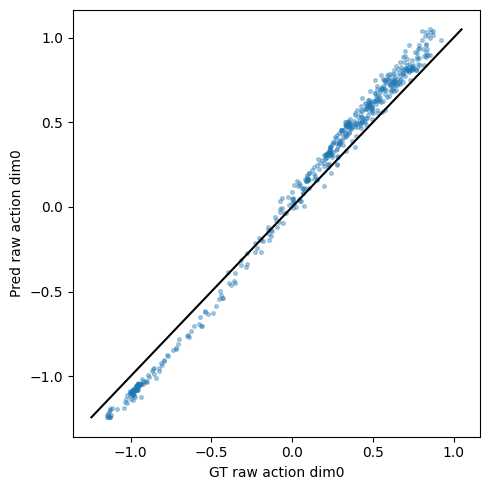

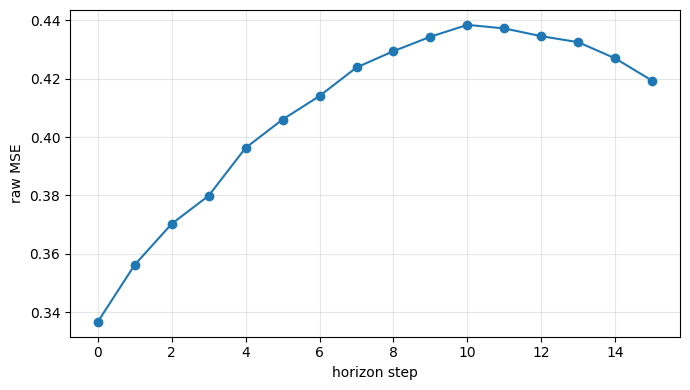

{
  "status": "completed",
  "eval_samples": 755702,
  "comparison_table": [
    {
      "model": "baseline_train_action_mean",
      "status": "completed",
      "input": "none",
      "stage": "baseline",
      "S": 1,
      "H": 16,
      "K": 0,
      "flow_matching_test_loss_normalized": NaN,
      "samples": 755702,
      "values": 532014208,
      "raw_mse": 0.6378114410069007,
      "raw_mae": 0.4209487847221178,
      "raw_rmse": 0.7986309792431675,
      "masked_raw_mse": 0.6378114410069007,
      "masked_raw_mae": 0.4209487847221178,
      "masked_raw_rmse": 0.7986309792431675,
      "zeroshot_model_id": null,
      "skip_reason": null,
      "elapsed_sec": NaN
    },
    {
      "model": "baseline_last_state_repeat",
      "status": "completed",
      "input": "state",
      "stage": "baseline",
      "S": 1,
      "H": 16,
      "K": 0,
      "flow_matching_test_loss_normalized": NaN,
      "samples": 755702,
      "values": 532014208,
      "raw_mse": 0.6160291988481595,


In [7]:
compare_df.to_csv(OUTPUT_ROOT/"eval_metrics.csv", index=False)
compare_df.to_csv(OUTPUT_ROOT/"baseline_vs_official_mini.csv", index=False)
subset_df.to_csv(OUTPUT_ROOT/"per_subset_metrics.csv", index=False)
h_df.to_csv(OUTPUT_ROOT/"per_horizon_metrics.csv", index=False)
dim_df.to_csv(OUTPUT_ROOT/"per_action_dim_metrics.csv", index=False)
if preview_t and preview_p:
    plt.figure(figsize=(5,5)); plt.scatter(preview_t, preview_p, s=7, alpha=.35); mn=min(preview_t+preview_p); mx=max(preview_t+preview_p); plt.plot([mn,mx],[mn,mx],color="black"); plt.xlabel("GT raw action dim0"); plt.ylabel("Pred raw action dim0"); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"prediction_vs_ground_truth_raw.png", dpi=160); plt.show()
if len(h_df):
    plt.figure(figsize=(7,4)); plt.plot(h_df.horizon_step, h_df.raw_mse, marker="o"); plt.xlabel("horizon step"); plt.ylabel("raw MSE"); plt.grid(True, alpha=.3); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/"horizon_error_curve_raw.png", dpi=160); plt.show()
summary = {"status":"completed", "eval_samples": int(len(ds)),
           "comparison_table": compare_df.where(pd.notnull(compare_df), None).to_dict("records"),
           "denormalized_raw_action_metrics": True, "uses_action_mask": True,
           "input_quality_report": input_quality_report,
           "run_root": str(RUN_ROOT), "prepared_roots": [str(r) for r in PREPARED_ROOTS], "encoded_roots": [str(info["root"]) for info in encoded_root_infos],
           "num_prepared_roots": len(PREPARED_ROOTS), "num_encoded_roots": len(encoded_root_infos),
           "train_summary": {k: train_summary.get(k) for k in ["status", "full_epoch_completed", "pretrain_completed", "posttrain_completed", "pretrain_samples", "posttrain_samples", "test_samples", "train_encoded", "test_encoded"]},
           "zeroshot_attempted": bool(RUN_NVIDIA_ZEROSHOT), "zeroshot_status": str(zeroshot_row.get("status")),
           "zeroshot_model_id": NVIDIA_MODEL_ID, "zeroshot_skip_reason": zeroshot_row.get("skip_reason"),
           "pretrain_eval_completed": bool(((compare_df.model == "OfficialMiniVLDiT_pretrain") & (compare_df.status == "completed")).any()),
           "posttrain_eval_completed": bool(((compare_df.model == "OfficialMiniVLDiT_posttrain") & (compare_df.status == "completed")).any()),
           "elapsed_sec": round(time.time()-start, 2)}
(OUTPUT_ROOT/"eval_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
for p in sorted(OUTPUT_ROOT.iterdir()): print("-", p.name, round(p.stat().st_size/(1024**2), 3), "MB")
